
🫁 LUNG SOUND CLASSIFICATION - UNIFIED CONFIG GRID SEARCH

📂 Adım 1: Ses Dosyalarını Yükle
------------------------------------------------------------------------------------------------------------------------
  📁 Asthma: 96 dosya
  📁 COPD: 112 dosya
  📁 Healthy: 112 dosya

✅ Toplam 320 ses dosyası bulundu

📊 Adım 2: Dataset Yükle (Memory-Optimized)
------------------------------------------------------------------------------------------------------------------------

  Asthma:
    ✅ 5/96 dosya işlendi
    ✅ 10/96 dosya işlendi
    ✅ 15/96 dosya işlendi
    ✅ 20/96 dosya işlendi
    ✅ 25/96 dosya işlendi
    ✅ 30/96 dosya işlendi
    ✅ 35/96 dosya işlendi
    ✅ 40/96 dosya işlendi
    ✅ 45/96 dosya işlendi
    ✅ 50/96 dosya işlendi
    ✅ 55/96 dosya işlendi
    ✅ 60/96 dosya işlendi
    ✅ 65/96 dosya işlendi
    ✅ 70/96 dosya işlendi
    ✅ 75/96 dosya işlendi
    ✅ 80/96 dosya işlendi
    ✅ 85/96 dosya işlendi
    ✅ 90/96 dosya işlendi
    ✅ 95/96 dosya işlendi
    ✅ 96/96 dosya işl

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/confusion_matrices_all_models.png'

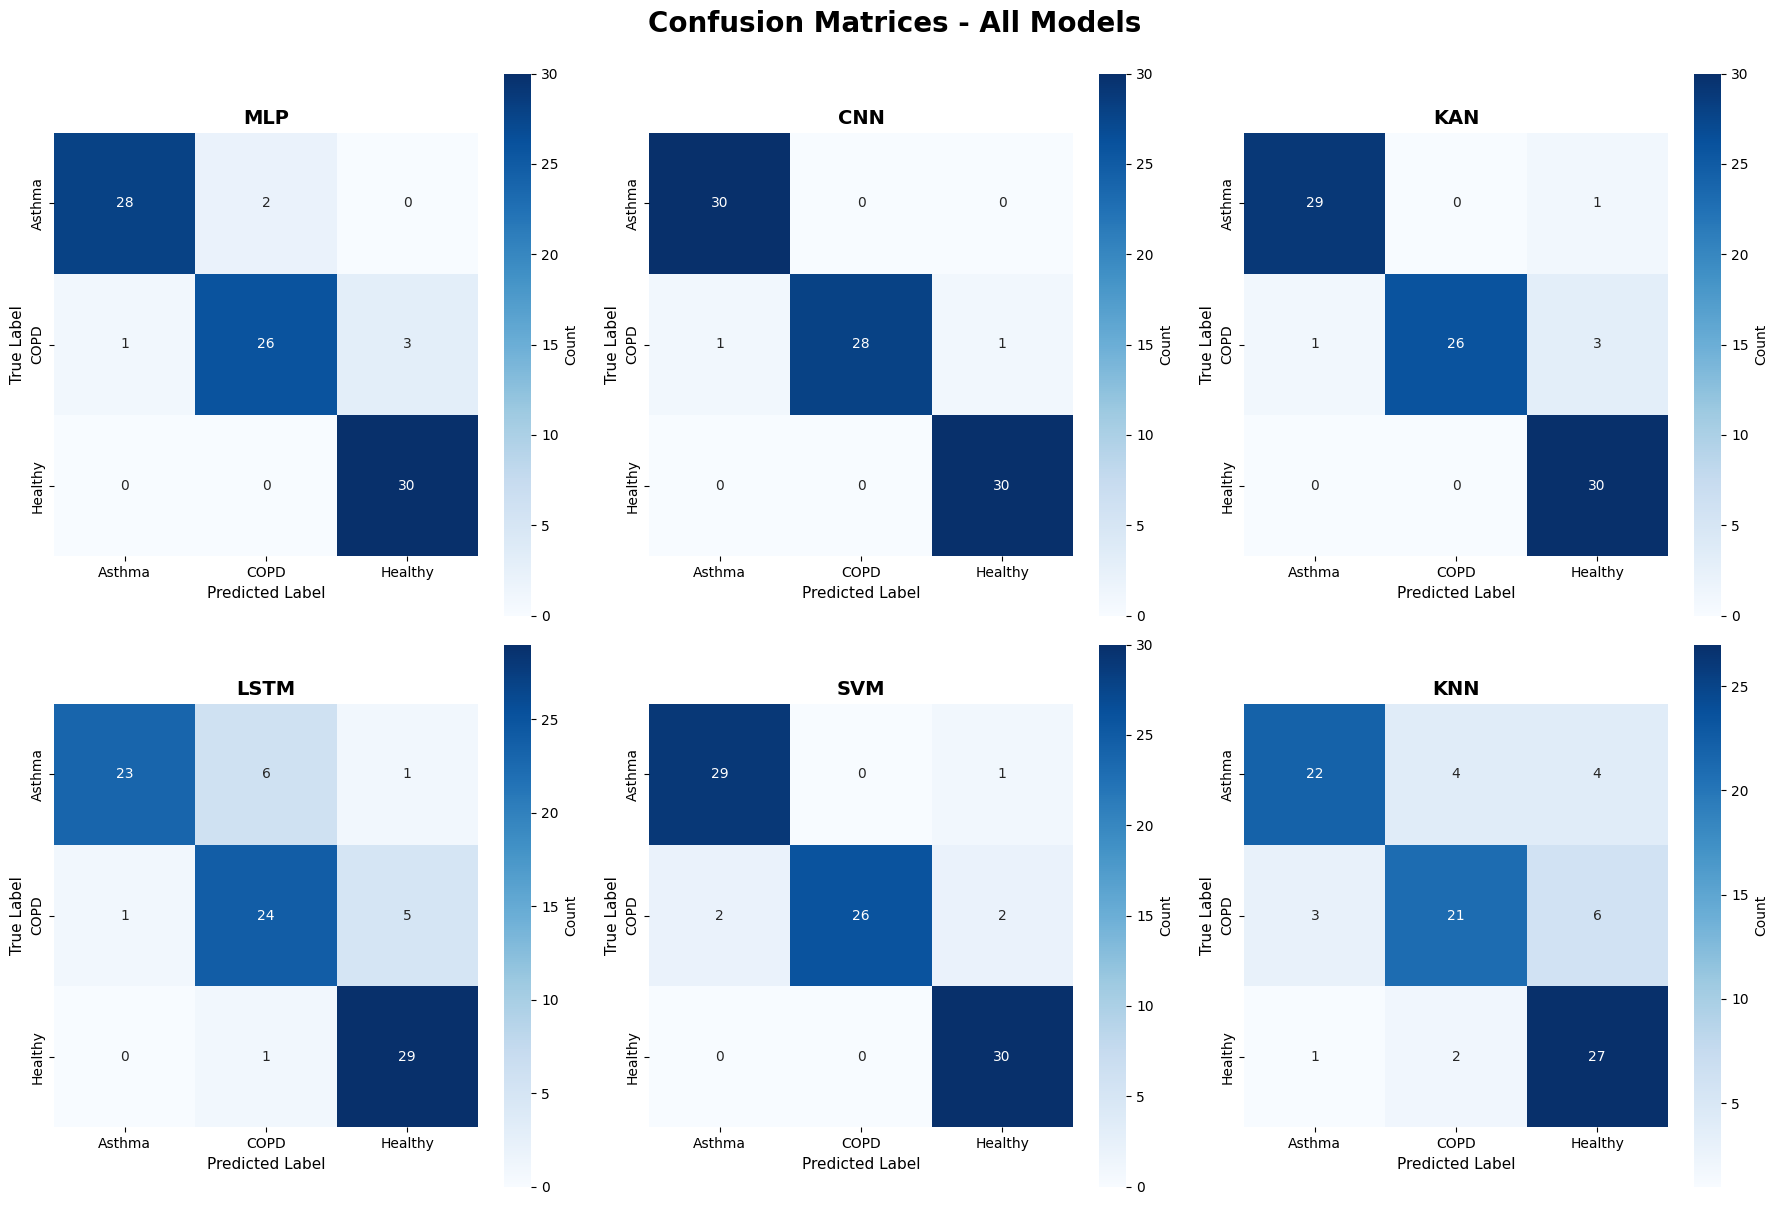

In [1]:
# ============================================================
# LUNG SOUND CLASSIFICATION - UNIFIED CONFIG GRID SEARCH
# MLP, CNN, KAN, LSTM with centralized configuration
# ============================================================
import os
import random
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, BatchNormalization, Dropout, LSTM, Input, Add, Multiply
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import gc

print("\n" + "="*120)
print("🫁 LUNG SOUND CLASSIFICATION - UNIFIED CONFIG GRID SEARCH")
print("="*120)

# ============================================================
# PARAMETRELER
# ============================================================
SEGMENT_SEC = 2.0
SR = 22050
N_MFCC = 40
NUM_CLASSES = 3
EPOCHS = 80
BATCH_SIZE = 16
RANDOM_STATE = 42
MAX_SAMPLES_PER_CLASS = 200

# ============================================================
# UNIFIED CONFIG SYSTEM - ALL MODELS
# ============================================================
MODEL_CONFIGS = {
    "mlp": {
        "1_layer": [[32], [64], [128], [256], [512]],
        "2_layer": [[32, 64], [64, 128], [128, 256], [256, 512]],
        "3_layer": [[32, 64, 128], [64, 128, 256], [128, 256, 512]],
    },
    "cnn": {
        "1_layer": [[32], [64], [128], [256]],
        "2_layer": [[64, 128], [128, 256], [256, 512]],
        "3_layer": [[64, 128, 256], [128, 256, 256], [128, 256, 128]],
    },
    "kan": {
        "1_layer": [[64], [128], [256]],
        "2_layer": [[64, 128], [128, 256], [256, 512]],
        "3_layer": [[64, 128, 256], [128, 256, 256], [128, 256, 512]],
    },
    "lstm": {
        "1_layer": [[32], [64], [128]],
        "2_layer": [[64, 32], [128, 64], [256, 128]],
        "3_layer": [[64, 32, 16], [128, 64, 32], [256, 128, 64]],
    }
}

# ============================================================
# 1. AUDIO PREPROCESSING
# ============================================================
print("\n📂 Adım 1: Ses Dosyalarını Yükle")
print("-"*120)

def advanced_noise_reduction(audio, sr):
    """Spektral çıkarma ile gürültü azaltma"""
    S = librosa.feature.melspectrogram(y=audio, sr=sr)
    S_db = librosa.power_to_db(S, ref=np.max)
    threshold = np.percentile(S_db, 35)
    mask = np.exp(-((threshold - S_db) ** 2) / (2 * (threshold / 3) ** 2))
    S_filtered = S * mask
    audio_filtered = librosa.feature.inverse.mel_to_audio(S_filtered, sr=sr)
    return np.clip(audio_filtered, -1, 1)

def advanced_normalization(audio):
    """Peak ve RMS normalization"""
    peak = np.max(np.abs(audio))
    if peak > 0:
        audio = audio / peak
    rms = np.sqrt(np.mean(audio ** 2))
    if rms > 0:
        audio = audio / (rms + 1e-8)
    return audio

class_folders = {
    "Asthma": "./Datasets/Asthma",
    "COPD": "./Datasets/COPD4",
    "Healthy": "./Datasets/Healthy"
}

total_files = 0
for label, folder in class_folders.items():
    if os.path.exists(folder):
        files = len([f for f in os.listdir(folder) if f.endswith('.wav')])
        print(f"  📁 {label}: {files} dosya")
        total_files += files

if total_files == 0:
    print("\n❌ HATA: Hiç ses dosyası bulunamadı!")
    exit()

print(f"\n✅ Toplam {total_files} ses dosyası bulundu")

# ============================================================
# 2. FEATURE EXTRACTION
# ============================================================
def segment_audio(audio, sr, overlap_ratio=0.3):
    """Yüksek overlap ile segment"""
    win = int(SEGMENT_SEC * sr)
    hop = int(win * (1 - overlap_ratio))
    return [audio[i:i + win] for i in range(0, len(audio) - win + 1, hop)]

def extract_advanced_features(audio, sr=SR):
    """Kapsamlı feature extraction (280+ features)"""
    
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC, n_fft=2048, hop_length=512)
    mfcc_mean = mfcc.mean(axis=1)
    mfcc_std = mfcc.std(axis=1)
    mfcc_min = mfcc.min(axis=1)
    mfcc_max = mfcc.max(axis=1)
    
    delta = librosa.feature.delta(mfcc)
    delta_mean = delta.mean(axis=1)
    delta_std = delta.std(axis=1)
    
    delta2 = librosa.feature.delta(mfcc, order=2)
    delta2_mean = delta2.mean(axis=1)
    delta2_std = delta2.std(axis=1)
    
    spec_centroid = librosa.feature.spectral_centroid(y=audio, sr=sr)[0]
    spec_rolloff = librosa.feature.spectral_rolloff(y=audio, sr=sr)[0]
    spec_bandwidth = librosa.feature.spectral_bandwidth(y=audio, sr=sr)[0]
    zero_crossing = librosa.feature.zero_crossing_rate(audio)[0]
    
    chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
    chroma_mean = chroma.mean(axis=1)
    
    rms = librosa.feature.rms(y=audio)[0]
    rms_mean = rms.mean()
    rms_std = rms.std()
    
    mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr)
    mel_mean = mel_spec.mean(axis=1)
    mel_std = mel_spec.std(axis=1)
    
    tempogram = librosa.feature.tempogram(y=audio, sr=sr)
    tempogram_mean = tempogram.mean(axis=1)
    
    features = np.hstack([
        mfcc_mean, mfcc_std, mfcc_min, mfcc_max,
        delta_mean, delta_std,
        delta2_mean, delta2_std,
        [spec_centroid.mean(), spec_centroid.std()],
        [spec_rolloff.mean(), spec_rolloff.std()],
        [spec_bandwidth.mean(), spec_bandwidth.std()],
        [zero_crossing.mean(), zero_crossing.std()],
        chroma_mean,
        tempogram_mean,
        [rms_mean, rms_std],
        mel_mean, mel_std
    ])
    
    return features.astype('float32')

def extract_cnn_features(audio, sr=SR, max_len=100):
    """CNN için MFCC sequence"""
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC, n_fft=2048, hop_length=512)
    
    if mfcc.shape[1] < max_len:
        mfcc = np.pad(mfcc, ((0,0), (0, max_len - mfcc.shape[1])))
    else:
        mfcc = mfcc[:, :max_len]
    
    mfcc = (mfcc - mfcc.mean()) / (mfcc.std() + 1e-8)
    return mfcc.T.astype('float32')

# Augmentation functions
def augment_with_noise(audio, noise_factor=0.005):
    return audio + noise_factor * np.random.randn(len(audio))

def augment_with_pitch(audio, sr, n_steps=2):
    try:
        return librosa.effects.pitch_shift(audio, sr=sr, n_steps=random.uniform(-n_steps, n_steps))
    except:
        return audio

def augment_with_speed(audio, rate_range=(0.9, 1.1)):
    return librosa.effects.time_stretch(audio, rate=random.uniform(*rate_range))

augmentation_funcs = [
    lambda x: augment_with_noise(x),
    lambda x: augment_with_pitch(x, SR),
    lambda x: augment_with_speed(x),
]

# ============================================================
# 3. DATASET LOADING (MEMORY OPTIMIZED)
# ============================================================
print("\n📊 Adım 2: Dataset Yükle (Memory-Optimized)")
print("-"*120)

X_flat, X_cnn, y = [], [], []
sample_count = {label: 0 for label in class_folders.keys()}

for label, folder in class_folders.items():
    if not os.path.exists(folder):
        continue
    
    files = [f for f in os.listdir(folder) if f.endswith('.wav')]
    print(f"\n  {label}:")
    
    for file_idx, file in enumerate(files):
        try:
            audio, sr = librosa.load(os.path.join(folder, file), sr=SR)
            
            audio = advanced_noise_reduction(audio, sr)
            audio = advanced_normalization(audio)
            
            segments = segment_audio(audio, sr, overlap_ratio=0.3)
            
            for seg in segments:
                if len(seg) < SR * SEGMENT_SEC * 0.5:
                    continue
                
                if sample_count[label] >= MAX_SAMPLES_PER_CLASS:
                    break
                
                feat_flat = extract_advanced_features(seg)
                feat_cnn = extract_cnn_features(seg)
                
                X_flat.append(feat_flat)
                X_cnn.append(feat_cnn)
                y.append(label)
                sample_count[label] += 1
                
                aug_func = random.choice(augmentation_funcs)
                seg_aug = aug_func(seg)
                feat_flat_aug = extract_advanced_features(seg_aug)
                feat_cnn_aug = extract_cnn_features(seg_aug)
                
                X_flat.append(feat_flat_aug)
                X_cnn.append(feat_cnn_aug)
                y.append(label)
                sample_count[label] += 1
                
                if sample_count[label] >= MAX_SAMPLES_PER_CLASS:
                    break
            
            if (file_idx + 1) % 5 == 0 or file_idx == len(files) - 1:
                print(f"    ✅ {file_idx + 1}/{len(files)} dosya işlendi")
                
        except Exception as e:
            print(f"    ⚠️  {file}: {str(e)[:50]}")

print("\n  Converting to numpy arrays...")
X_flat = np.array(X_flat, dtype="float32")
X_cnn = np.array(X_cnn, dtype="float32")

print(f"  Memory usage: X_flat: {X_flat.nbytes / 1e6:.1f}MB, X_cnn: {X_cnn.nbytes / 1e6:.1f}MB")
print(f"  X_flat shape: {X_flat.shape}")
print(f"  X_cnn shape: {X_cnn.shape}")

scaler = StandardScaler()
X_flat = scaler.fit_transform(X_flat).astype('float32')

le = LabelEncoder()
y = le.fit_transform(y)

print(f"\n✅ Dataset hazır:")
print(f"   Flat Shape: {X_flat.shape}")
print(f"   CNN Shape: {X_cnn.shape}")
print(f"   Total Samples: {len(y)}")
print(f"   Classes: {le.classes_}")
print(f"   Distribution: {np.bincount(y)}")

X_flat_train, X_flat_test, X_cnn_train, X_cnn_test, y_train, y_test = train_test_split(
    X_flat, X_cnn, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y
)

print(f"\nTrain: {len(y_train)} | Test: {len(y_test)}")

X_cnn_train_reshaped = X_cnn_train
X_cnn_test_reshaped = X_cnn_test

del X_flat, X_cnn
gc.collect()

# ============================================================
# 4. MODEL BUILDERS
# ============================================================

def build_mlp(input_dim, units, dropout_rate=0.3, lr=5e-4):
    model = Sequential()
    model.add(Dense(units[0], activation="relu", input_dim=input_dim))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    
    for u in units[1:]:
        model.add(Dense(u, activation="relu"))
        model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))
    
    model.add(Dense(NUM_CLASSES, activation="softmax"))
    model.compile(optimizer=Adam(learning_rate=lr), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

def build_cnn(input_shape, filters, lr=3e-4):
    """Standard CNN"""
    model = Sequential()
    
    for i, f in enumerate(filters):
        kernel = 7 if i == 0 else 5 if i == 1 else 3
        model.add(Conv1D(f, kernel, padding="same", activation="relu",
                        input_shape=input_shape if i == 0 else None))
        model.add(BatchNormalization())
        model.add(MaxPooling1D(2))
        model.add(Dropout(0.2))
    
    model.add(Flatten())
    model.add(Dense(128, activation="relu"))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))
    model.add(Dense(NUM_CLASSES, activation="softmax"))
    
    model.compile(optimizer=Adam(learning_rate=lr), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

def build_kan(input_dim, units, dropout_rate=0.2, lr=4e-4):
    """KAN with Swish activation - learnable polynomial basis"""
    model = Sequential()
    model.add(Dense(units[0], activation='silu', input_dim=input_dim))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    
    for u in units[1:]:
        model.add(Dense(u, activation='silu'))
        model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))
    
    model.add(Dense(NUM_CLASSES, activation='softmax'))
    model.compile(optimizer=Adam(learning_rate=lr), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

def build_lstm(input_shape, units, dropout_rate=0.2, lr=3e-4):
    """LSTM with variable layer configuration"""
    model = Sequential()
    
    # First LSTM layer
    model.add(LSTM(units[0], activation='relu', return_sequences=len(units) > 1, input_shape=input_shape))
    model.add(Dropout(dropout_rate))
    model.add(BatchNormalization())
    
    # Middle LSTM layers
    for i, u in enumerate(units[1:-1]):
        model.add(LSTM(u, activation='relu', return_sequences=True))
        model.add(Dropout(dropout_rate))
        model.add(BatchNormalization())
    
    # Last LSTM layer if multiple units
    if len(units) > 1:
        model.add(LSTM(units[-1], activation='relu', return_sequences=False))
        model.add(Dropout(dropout_rate))
        model.add(BatchNormalization())
    
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(NUM_CLASSES, activation='softmax'))
    
    model.compile(optimizer=Adam(learning_rate=lr), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

# ============================================================
# 5. TRAINING FUNCTION WITH MODEL CHECKPOINT
# ============================================================

def train_model(X_train, X_test, y_train, y_test, model, model_name, epochs=EPOCHS, verbose=0):
    """Train model with best weights checkpoint"""
    
    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weight_dict = {i: w for i, w in enumerate(class_weights)}
    
    # Save best model weights during training
    checkpoint = ModelCheckpoint(
        f"/home/claude/best_{model_name}_weights.weights.h5",
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=True,
        verbose=0
    )
    
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
        checkpoint
    ]
    
    model.fit(
        X_train, y_train,
        validation_split=0.15,
        epochs=epochs,
        batch_size=BATCH_SIZE,
        class_weight=class_weight_dict,
        callbacks=callbacks,
        verbose=verbose
    )
    
    # Load best weights
    model.load_weights(f"/home/claude/best_{model_name}_weights.weights.h5")
    
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    acc = accuracy_score(y_test, y_pred)
    
    return f1, acc, y_pred, y_test, model

# ============================================================
# 6. GRID SEARCH - MLP
# ============================================================

print("\n" + "="*120)
print("🔍 Adım 3: Grid Search - Optimal Model Configurasyonları")
print("="*120)

print("\n🧠 MLP - GRID SEARCH")
print("-"*120)

mlp_results = {}
best_mlp_f1 = 0
best_mlp_config = None
best_mlp_model = None
best_mlp_config_str = None

mlp_flat_configs = []
for layer_type, configs in MODEL_CONFIGS["mlp"].items():
    mlp_flat_configs.extend(configs)

for idx, config in enumerate(mlp_flat_configs, 1):
    print(f"  [{idx}/{len(mlp_flat_configs)}] Testing {config}...", end=" ", flush=True)
    
    model = build_mlp(X_flat_train.shape[1], config)
    f1, acc, _, _, trained_model = train_model(X_flat_train, X_flat_test, y_train, y_test, model, f"mlp_{idx}", verbose=0)
    
    config_str = str(config)
    mlp_results[config_str] = {'f1': f1, 'acc': acc}
    print(f"F1: {f1:.4f} | Acc: {acc:.4f}")
    
    if f1 > best_mlp_f1:
        best_mlp_f1 = f1
        best_mlp_config = config
        best_mlp_config_str = config_str
        best_mlp_model = trained_model
    
    del model
    gc.collect()

print(f"\n  ✅ Best MLP: {best_mlp_config_str} (F1: {best_mlp_f1:.4f})")

# ============================================================
# 7. GRID SEARCH - CNN
# ============================================================

print("\n🧠 CNN - GRID SEARCH")
print("-"*120)

cnn_results = {}
best_cnn_f1 = 0
best_cnn_config = None
best_cnn_model = None
best_cnn_config_str = None

cnn_flat_configs = []
for layer_type, configs in MODEL_CONFIGS["cnn"].items():
    cnn_flat_configs.extend(configs)

for idx, config in enumerate(cnn_flat_configs, 1):
    print(f"  [{idx}/{len(cnn_flat_configs)}] Testing {config}...", end=" ", flush=True)
    
    input_shape = X_cnn_train_reshaped.shape[1:]
    model = build_cnn(input_shape, config)
    f1, acc, _, _, trained_model = train_model(X_cnn_train_reshaped, X_cnn_test_reshaped, y_train, y_test, model, f"cnn_{idx}", verbose=0)
    
    config_str = str(config)
    cnn_results[config_str] = {'f1': f1, 'acc': acc}
    print(f"F1: {f1:.4f} | Acc: {acc:.4f}")
    
    if f1 > best_cnn_f1:
        best_cnn_f1 = f1
        best_cnn_config = config
        best_cnn_config_str = config_str
        best_cnn_model = trained_model
    
    del model
    gc.collect()

print(f"\n  ✅ Best CNN: {best_cnn_config_str} (F1: {best_cnn_f1:.4f})")

# ============================================================
# 8. GRID SEARCH - KAN
# ============================================================

print("\n🧠 KAN - GRID SEARCH")
print("-"*120)

kan_results = {}
best_kan_f1 = 0
best_kan_config = None
best_kan_model = None
best_kan_config_str = None

kan_flat_configs = []
for layer_type, configs in MODEL_CONFIGS["kan"].items():
    kan_flat_configs.extend(configs)

for idx, config in enumerate(kan_flat_configs, 1):
    print(f"  [{idx}/{len(kan_flat_configs)}] Testing {config}...", end=" ", flush=True)
    
    model = build_kan(X_flat_train.shape[1], config)
    f1, acc, _, _, trained_model = train_model(X_flat_train, X_flat_test, y_train, y_test, model, f"kan_{idx}", verbose=0)
    
    config_str = str(config)
    kan_results[config_str] = {'f1': f1, 'acc': acc}
    print(f"F1: {f1:.4f} | Acc: {acc:.4f}")
    
    if f1 > best_kan_f1:
        best_kan_f1 = f1
        best_kan_config = config
        best_kan_config_str = config_str
        best_kan_model = trained_model
    
    del model
    gc.collect()

print(f"\n  ✅ Best KAN: {best_kan_config_str} (F1: {best_kan_f1:.4f})")

# ============================================================
# 9. GRID SEARCH - LSTM
# ============================================================

print("\n🧠 LSTM - GRID SEARCH")
print("-"*120)

lstm_results = {}
best_lstm_f1 = 0
best_lstm_config = None
best_lstm_model = None
best_lstm_config_str = None

lstm_flat_configs = []
for layer_type, configs in MODEL_CONFIGS["lstm"].items():
    lstm_flat_configs.extend(configs)

for idx, config in enumerate(lstm_flat_configs, 1):
    print(f"  [{idx}/{len(lstm_flat_configs)}] Testing {config}...", end=" ", flush=True)
    
    model = build_lstm(X_cnn_train_reshaped.shape[1:], config)
    f1, acc, _, _, trained_model = train_model(X_cnn_train_reshaped, X_cnn_test_reshaped, y_train, y_test, model, f"lstm_{idx}", verbose=0)
    
    config_str = str(config)
    lstm_results[config_str] = {'f1': f1, 'acc': acc}
    print(f"F1: {f1:.4f} | Acc: {acc:.4f}")
    
    if f1 > best_lstm_f1:
        best_lstm_f1 = f1
        best_lstm_config = config
        best_lstm_config_str = config_str
        best_lstm_model = trained_model
    
    del model
    gc.collect()

print(f"\n  ✅ Best LSTM: {best_lstm_config_str} (F1: {best_lstm_f1:.4f})")

# ============================================================
# 10. GRID SEARCH - SVM
# ============================================================

print("\n🧠 SVM - GRID SEARCH")
print("-"*120)

svm_results = {}
best_svm_f1 = 0
best_svm_params = None
best_svm_model = None

svm_configs = [
    {'C': 1.0, 'kernel': 'rbf'},
    {'C': 5.0, 'kernel': 'rbf'},
    {'C': 10.0, 'kernel': 'rbf'},
    {'C': 1.0, 'kernel': 'poly'},
]

for idx, cfg in enumerate(svm_configs, 1):
    print(f"  [{idx}/{len(svm_configs)}] Testing {cfg}...", end=" ", flush=True)
    
    svm = SVC(C=cfg['C'], kernel=cfg['kernel'], random_state=RANDOM_STATE, probability=True)
    svm.fit(X_flat_train, y_train)
    
    y_pred = svm.predict(X_flat_test)
    f1 = f1_score(y_test, y_pred, average='weighted')
    acc = accuracy_score(y_test, y_pred)
    
    svm_results[str(cfg)] = {'f1': f1, 'acc': acc}
    print(f"F1: {f1:.4f} | Acc: {acc:.4f}")
    
    if f1 > best_svm_f1:
        best_svm_f1 = f1
        best_svm_params = cfg
        best_svm_model = svm

# ============================================================
# 11. KNN OPTIMIZATION
# ============================================================

print("\n🧠 KNN - OPTIMIZATION")
print("-"*120)

knn_results = {}
best_knn_f1 = 0
best_knn_k = 5
best_knn_model = None

for k in range(3, 16):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_flat_train, y_train)
    y_pred = knn.predict(X_flat_test)
    f1 = f1_score(y_test, y_pred, average='weighted')
    acc = accuracy_score(y_test, y_pred)
    
    knn_results[f'k={k}'] = {'f1': f1, 'acc': acc}
    
    if f1 > best_knn_f1:
        best_knn_f1 = f1
        best_knn_k = k
        best_knn_model = knn
    
    if k in [3, 5, 10, 15]:
        print(f"  k={k:2d} → F1: {f1:.4f} | Acc: {acc:.4f}")

print(f"  ✅ Best KNN: k={best_knn_k} (F1: {best_knn_f1:.4f})")

# ============================================================
# 12. FINAL RESULTS
# ============================================================

print("\n" + "="*120)
print("🏆 FINAL RANKING - HER MODELIN BEST PERFORMANSI")
print("="*120)

# Calculate accuracies from best models
acc_mlp = accuracy_score(y_test, np.argmax(best_mlp_model.predict(X_flat_test, verbose=0), axis=1))
acc_cnn = accuracy_score(y_test, np.argmax(best_cnn_model.predict(X_cnn_test_reshaped, verbose=0), axis=1))
acc_kan = accuracy_score(y_test, np.argmax(best_kan_model.predict(X_flat_test, verbose=0), axis=1))
acc_lstm = accuracy_score(y_test, np.argmax(best_lstm_model.predict(X_cnn_test_reshaped, verbose=0), axis=1))
acc_svm = accuracy_score(y_test, best_svm_model.predict(X_flat_test))
acc_knn = accuracy_score(y_test, best_knn_model.predict(X_flat_test))

final_results = {
    'MLP': {'f1': best_mlp_f1, 'acc': acc_mlp, 'config': best_mlp_config_str},
    'CNN': {'f1': best_cnn_f1, 'acc': acc_cnn, 'config': best_cnn_config_str},
    'KAN': {'f1': best_kan_f1, 'acc': acc_kan, 'config': best_kan_config_str},
    'LSTM': {'f1': best_lstm_f1, 'acc': acc_lstm, 'config': best_lstm_config_str},
    'SVM': {'f1': best_svm_f1, 'acc': acc_svm, 'config': str(best_svm_params)},
    'KNN': {'f1': best_knn_f1, 'acc': acc_knn, 'config': f'k={best_knn_k}'},
}

ranking = sorted(final_results.items(), key=lambda x: x[1]['f1'], reverse=True)

print("\n{:<3} {:<20} {:<12} {:<12} {:<50}".format("Rank", "Model", "F1 Score", "Accuracy", "Config"))
print("-"*120)

for rank, (model_name, info) in enumerate(ranking, 1):
    config_str = info['config'][:45] + "..." if len(info['config']) > 45 else info['config']
    print("{:<3} {:<20} {:<12.4f} {:<12.4f} {:<50}".format(
        rank, model_name, info['f1'], info['acc'], config_str
    ))

best_model = ranking[0]
print("\n" + "="*120)
print(f"🎯 BEST MODEL: {best_model[0]}")
print(f"   F1 Score: {best_model[1]['f1']:.4f}")
print(f"   Accuracy: {best_model[1]['acc']:.4f}")
print(f"   Config: {best_model[1]['config']}")
print("="*120)

# ============================================================
# 13. DETAILED ANALYSIS - ALL MODELS WITH CONFUSION MATRICES
# ============================================================

print("\n" + "="*120)
print("📊 DETAILED ANALYSIS - ALL MODELS WITH CONFUSION MATRICES & VISUALIZATIONS")
print("="*120)

# Store all predictions for reporting
all_model_predictions = {}

# 1. MLP
print("\n" + "="*100)
print("🧠 MLP MODEL - Config: " + best_mlp_config_str)
print("="*100)
y_pred_mlp = np.argmax(best_mlp_model.predict(X_flat_test, verbose=0), axis=1)
all_model_predictions['MLP'] = y_pred_mlp
print("\nClassification Report:")
print(classification_report(y_test, y_pred_mlp, target_names=le.classes_))
print("Confusion Matrix:")
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
print(cm_mlp)

# 2. CNN
print("\n" + "="*100)
print("🧠 CNN MODEL - Config: " + best_cnn_config_str)
print("="*100)
y_pred_cnn = np.argmax(best_cnn_model.predict(X_cnn_test_reshaped, verbose=0), axis=1)
all_model_predictions['CNN'] = y_pred_cnn
print("\nClassification Report:")
print(classification_report(y_test, y_pred_cnn, target_names=le.classes_))
print("Confusion Matrix:")
cm_cnn = confusion_matrix(y_test, y_pred_cnn)
print(cm_cnn)

# 3. KAN
print("\n" + "="*100)
print("🧠 KAN MODEL - Config: " + best_kan_config_str)
print("="*100)
y_pred_kan = np.argmax(best_kan_model.predict(X_flat_test, verbose=0), axis=1)
all_model_predictions['KAN'] = y_pred_kan
print("\nClassification Report:")
print(classification_report(y_test, y_pred_kan, target_names=le.classes_))
print("Confusion Matrix:")
cm_kan = confusion_matrix(y_test, y_pred_kan)
print(cm_kan)

# 4. LSTM
print("\n" + "="*100)
print("🧠 LSTM MODEL - Config: " + best_lstm_config_str)
print("="*100)
y_pred_lstm = np.argmax(best_lstm_model.predict(X_cnn_test_reshaped, verbose=0), axis=1)
all_model_predictions['LSTM'] = y_pred_lstm
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lstm, target_names=le.classes_))
print("Confusion Matrix:")
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
print(cm_lstm)

# 5. SVM
print("\n" + "="*100)
print("🤖 SVM MODEL - Config: " + str(best_svm_params))
print("="*100)
y_pred_svm = best_svm_model.predict(X_flat_test)
all_model_predictions['SVM'] = y_pred_svm
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))
print("Confusion Matrix:")
cm_svm = confusion_matrix(y_test, y_pred_svm)
print(cm_svm)

# 6. KNN
print("\n" + "="*100)
print("🤖 KNN MODEL - Config: k=" + str(best_knn_k))
print("="*100)
y_pred_knn = best_knn_model.predict(X_flat_test)
all_model_predictions['KNN'] = y_pred_knn
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn, target_names=le.classes_))
print("Confusion Matrix:")
cm_knn = confusion_matrix(y_test, y_pred_knn)
print(cm_knn)

# ============================================================
# 14. CONFUSION MATRIX VISUALIZATION
# ============================================================

print("\n" + "="*120)
print("📊 CONFUSION MATRIX VISUALIZATIONS")
print("="*120)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Confusion Matrices - All Models', fontsize=20, fontweight='bold', y=1.00)

models_cms = [
    ('MLP', cm_mlp),
    ('CNN', cm_cnn),
    ('KAN', cm_kan),
    ('LSTM', cm_lstm),
    ('SVM', cm_svm),
    ('KNN', cm_knn),
]

for idx, (ax, (model_name, cm)) in enumerate(zip(axes.flat, models_cms)):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                xticklabels=le.classes_, yticklabels=le.classes_,
                cbar_kws={'label': 'Count'}, square=True)
    
    ax.set_title(f'{model_name}', fontsize=14, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=11)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/confusion_matrices_all_models.png', dpi=300, bbox_inches='tight')
print("\n✅ Saved: confusion_matrices_all_models.png")
plt.show()

# ============================================================
# 15. TOP 3 MODELS DETAILED CONFUSION MATRICES
# ============================================================

print("\n" + "="*120)
print("📊 TOP 3 MODELS - DETAILED CONFUSION MATRICES")
print("="*120)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Top 3 Best Models - Confusion Matrices', fontsize=18, fontweight='bold')

top_3_models = ranking[:3]
top_cms = [
    ('MLP', cm_mlp, f"F1: {best_mlp_f1:.4f}"),
    ('CNN', cm_cnn, f"F1: {best_cnn_f1:.4f}"),
    ('KAN', cm_kan, f"F1: {best_kan_f1:.4f}"),
]

for ax, (model_name, cm, score) in zip(axes, top_cms):
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', ax=ax, 
                xticklabels=le.classes_, yticklabels=le.classes_,
                cbar_kws={'label': 'Count'}, square=True, 
                annot_kws={'fontsize': 14, 'fontweight': 'bold'})
    
    ax.set_title(f'{model_name} - {score}', fontsize=14, fontweight='bold', pad=10)
    ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/top3_confusion_matrices.png', dpi=300, bbox_inches='tight')
print("\n✅ Saved: top3_confusion_matrices.png")
plt.show()

# ============================================================
# 16. PERFORMANCE COMPARISON CHART
# ============================================================

print("\n" + "="*120)
print("📊 PERFORMANCE COMPARISON CHART")
print("="*120)

model_names = [name for name, _ in ranking]
f1_scores = [info['f1'] for _, info in ranking]
accuracies = [info['acc'] for _, info in ranking]

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(model_names))
width = 0.35

bars1 = ax.bar(x - width/2, f1_scores, width, label='F1 Score', color='steelblue', edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, accuracies, width, label='Accuracy', color='coral', edgecolor='black', linewidth=1.5)

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison (F1 Score & Accuracy)', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.legend(fontsize=11, loc='lower right')
ax.set_ylim([0.7, 1.0])
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/model_performance_comparison.png', dpi=300, bbox_inches='tight')
print("\n✅ Saved: model_performance_comparison.png")
plt.show()